# Potential drought impacts on agriculture [Hazard Assessment] 
Click [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/CLIMAAX/DROUGHT/main?labpath=DROUGHT_Hazard_Assessment.ipynb) to launch this notebook on MyBinder.</br>
Click [![Drought](https://img.shields.io/badge/DROUGHT-repository-blue)](https://github.com/CLIMAAX/DROUGHT/tree/main) to go to this workflow's GitHub repository.

## Hazard assessment methodology
Introduction to Standardised Precipitation-Evapotranspiration Index (SPEI). How was computed, which data feeds the calculations, spatial resolution and which models and scenarios are available.

Post processing of SPEI to get more insights of Drought hazard. What is the threshold to define severe and extreme drought.

Maybe connect to Copernicus Atlas where it is possible to explore SPEI6 (is it the same as this one?)

## Prepare your workspace
:::{admonition} Find out about the Python libraries we will use in this notebook.
:class: hint dropdown
<!-- * [cdsapi](https://cds.climate.copernicus.eu/api-how-to) - A library to request data from the datasets listed in the CDS catalogue. -->
* [numpy](https://numpy.org/doc/stable/) - A powerful library for numerical computations in Python, widely used for array operations and mathematical functions.
* [xarray](https://docs.xarray.dev/en/stable/) - Introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays for a more intuitive experience.
* [rioxarray](https://corteva.github.io/rioxarray/stable/) - An extension of the xarray library that simplifies working with geospatial raster data.
* [scipy](https://docs.scipy.org/doc/scipy/) - Provides algorithms for optimization, statistics and many other classes of problems.
* [matplotlib](https://matplotlib.org/stable/) -  A versatile plotting library in Python, commonly used for creating static, animated, and interactive visualizations.
* [cartopy](https://scitools.org.uk/cartopy/docs/latest/) - A package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
* [contextily](https://contextily.readthedocs.io/en/latest/) - To retrieve matplotlib compatible tile maps from the internet.

### Load libraries

In [28]:
# Libraries to download data and manage files
import os
import zipfile
import glob

# Libraries for numerical computations, array manipulation and statistics.
import numpy as np
import xarray as xr

# Libraries to handle geospatial data
import rioxarray as rio
import pyproj

# Libraries to compute climate indicators and indices
import xclim.indices as xci

# Libraries to plot maps, charts and tables
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import plotly.express as px
import contextily as ctx

# Choosing the matplotlib backend
%matplotlib inline

### Setting your directory
The next cell will create the *drought_workflow* directory in the same directory where the notebook is saved.

In [29]:
# Define the directory for the heavy workflow preprocess
workflow_dir = 'drought_workflow'

# Define directories for data and results within the previously defined workflow directory
data_dir = os.path.join(workflow_dir, 'data')
results_dir = os.path.join(workflow_dir, 'results')

# Create the workflow directory if it doesn't exists, along with subdirectories for data and results.
os.makedirs(workflow_dir, exist_ok = True)
os.makedirs(data_dir, exist_ok = True)
os.makedirs(results_dir, exist_ok = True)

### Select your area of study

Before downloading the data, let us define the coordinates of the area of interest. Based on these coordinates we will be able to clip the datasets for further processing, and eventually display hazard maps for the selected area.

To easily define an area in terms of geographical coordinates, you can go to the [Bounding Box Tool](https://boundingbox.klokantech.com) to select a region and get the coordinates. Make sure to select ‘CSV’ in the lower left corner and copy the values in the brackets below.

In [30]:
bbox = [0,40,4,44]; areaname = 'Catalonia'

---

## Step 1: Download SPEI dataset

In [31]:
# Code to download SPEI dataset from Cloud (waiting for implementation)
# Or maybe use the dataset availble from CDS directly with cdsapi (right now only SPI6, but 32 members).
# Right now, it is necessary to have the SPEI files in the directory defined as data_dir in order to work.

Extract the downloaded files to your data directory.

In [32]:
#with zipfile.ZipFile(zip_path, 'r') as zObject:
#    zObject.extractall(path=data_dir)

---

## Step 2: Explore the SPEI dataset
The SPEI files downloaded have a filename structure that describes the exact dataset contained. The general structure is the following:

<p style="text-align: center;">SPEI[month aggregation]_[gcm]_[ssp]_RF_[reference period]_[years available]</p>

Load one of the files and explore the content and structure of the dataset. Notice the dimensions, coordinates,  data variables, indexes and attributes.

In [33]:
# Define the path to a specific file
filename_spei_example = 'drought_workflow/data/SPEI6_mri-esm2-0_ssp370_RF_1951-2000_2015-2100_Catalonia.nc'
# Open the netCDF file as a dataset using xarray
ds_spei_example = xr.open_dataset(filename_spei_example, decode_coords = 'all')

print(os.path.basename(filename_spei_example))
# Display said dataset
ds_spei_example

SPEI6_mri-esm2-0_ssp370_RF_1951-2000_2015-2100_Catalonia.nc


<xarray.Dataset> Size: 273kB
Dimensions:      (lon: 8, lat: 8, time: 1032)
Coordinates:
  * lon          (lon) float64 64B 0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75
  * lat          (lat) float64 64B 40.25 40.75 41.25 41.75 ... 42.75 43.25 43.75
  * time         (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16...
    spatial_ref  int64 8B ...
Data variables:
    SPEI         (time, lat, lon) float32 264kB ...

Let's plot this dataset for a specific months and years. Notice that latitude and longitude are defined following the usual Coordinate Reference System (CRS) known as WGS84, although the latitude coordinate decreases.

In [34]:
# Define SPEI dataset's CRS.
crs = ccrs.Projection('EPSG:4326')

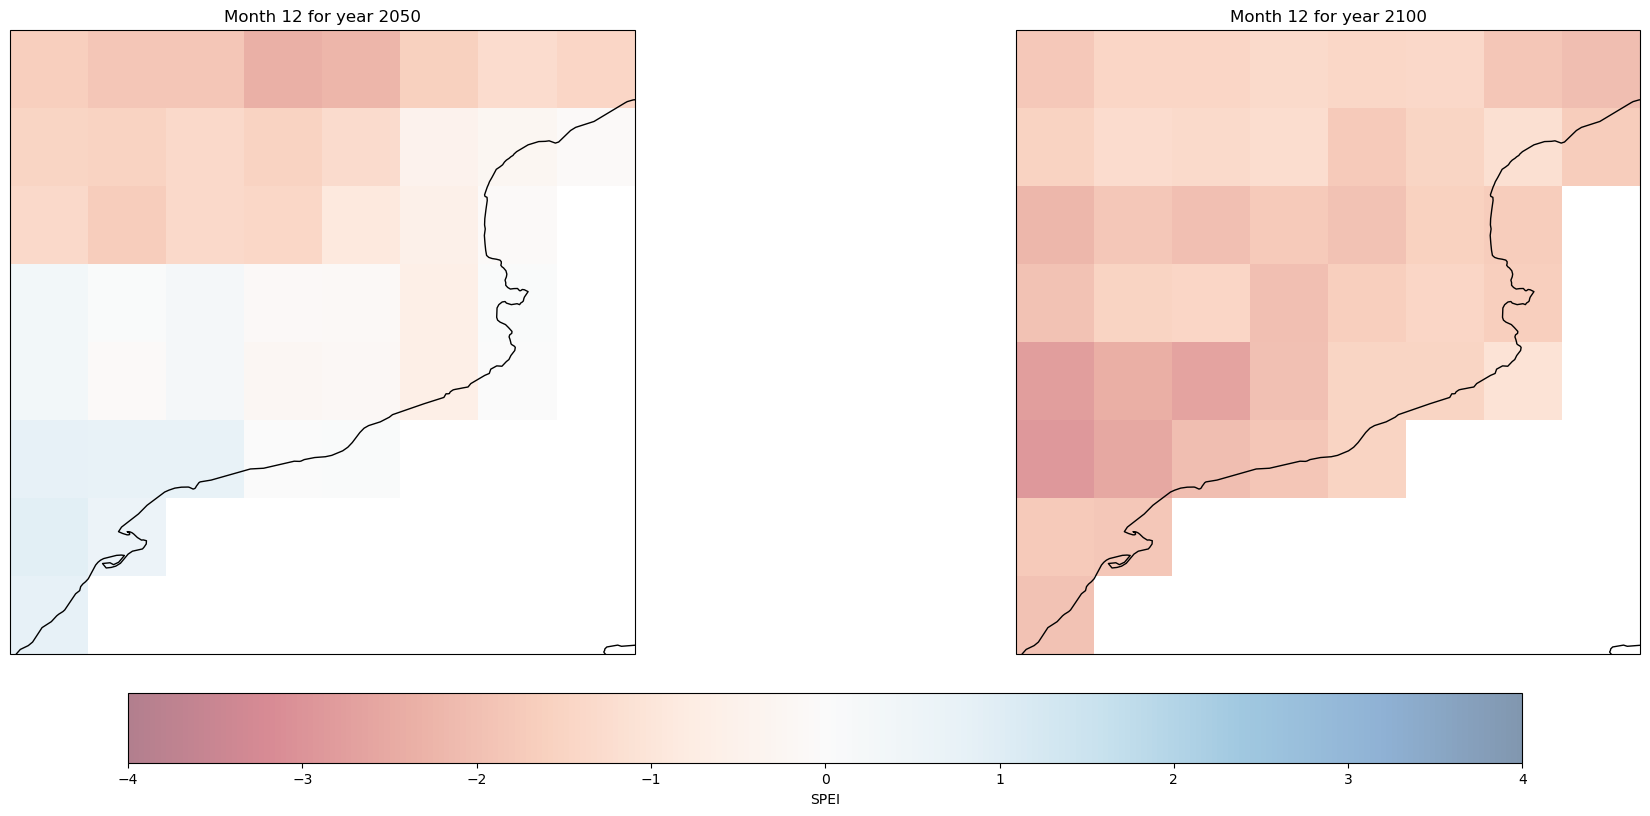

In [35]:
MONTHS = [12]
YEARS = [2050, 2100]

# Create matplotlib figure
fig, axes = plt.subplots(len(MONTHS), len(YEARS), figsize = (10*len(YEARS),8*len(MONTHS)), layout = 'constrained', sharey= True, subplot_kw={'projection': crs} )

for i, year_i in enumerate(YEARS):
    # Select year in the dataset
    ds_year = ds_spei_example.SPEI.isel(time = ds_spei_example.time.dt.year.isin(year_i))
    for j, month_j in enumerate(MONTHS):
        ax = axes[j,i] if len(MONTHS) != 1 else axes[i]
        # Select month.
        pcm = ds_year.isel(time = ds_year.time.dt.month.isin(month_j)).plot(ax = ax, cmap='RdBu', alpha = 0.5, vmin = -4, vmax = 4, add_colorbar=False)
        ax.set_title(f'Month {month_j} for year {year_i}')
        ax.add_feature(cfeature.COASTLINE)
        # ctx.add_basemap(ax = ax,crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, attribution=False)
fig.colorbar(pcm, ax = axes[-1,:] if len(MONTHS) != 1 else axes[:], location = 'bottom', shrink = 0.7, label = 'SPEI')
plt.show()

The extent of this dataset is global, therefore the number of points along latitude and longitude axes is very large. This dataset needs to be clipped to our area of interest. It can also be reprojected to a specific CRS in order to match local data. 

:::{note}
The SPEI dataset has a somewhat coarse spatial resolution. Please modify your defined bounding box if the new local dataset has no longitude or latitude points.
:::

## Step 3: Clip dataset to local area.
In order to asses how drought is going to change, we will need to load and clip the datasets for both historical (1951-2014) and future simulations (2015-2100).

In [36]:
# Select which dataset
T_AGG = 6 # Temporal aggregation of SPEI
GCM = 'mri-esm2-0' # Global climate model
SSP = 'ssp370' # Shares-socioeconomic pathway for future simulations

In [37]:
# Load both historical and future period
#for run in ['historical', SSP]:
#    # Read the specific file 
#    file_i = glob.glob(os.path.join('data',f'SPEI{T_AGG}_{GCM}_{run}_*[0-9].nc'))[0]#

    #file_i = f'data/SPEI{T_AGG}_{GCM}_{run}_*[0-9].nc'
    #file_i = filename_spei_example
#    ds_i = xr.open_dataset(file_i, decode_coords = 'all')
    # Invert latitude coordinate.
#    ds_i = ds_i.isel(lat=slice(None, None, -1))
    # Write CRS and clip to box
#    ds_i_clip = ds_i.SPEI.rio.write_crs(crs).rio.clip_box(*bbox)
    # Name of the clipped file
#    file_out_i = os.path.basename(file_i).replace('.nc', f'_{areaname}.nc')
#    print(file_out_i)
#    # Save netCDF in restults directory
#    ds_i_clip.to_netcdf(os.path.join(data_dir, file_out_i))

## Step 4: Calculate some drought characterisitcs.
Following [Chiang et al](https://doi.org/10.1038/s41467-021-22314-w), we will compute drought frequency, maximum duration of drougth events and maximum intensity of drought events.

In this example, two 30-year windows are selected: a historical one (1985-2014) and a future horizon (2041-2070).

In [38]:
# Define thresholds for drought definition
THRESHOLDS = { 
    'severe' : -1.5,
    'extreme' : -2
}

# Define year windows for each period.
YEAR_WINDOWS = {
    'historical' : ['1951', '2000'],
    SSP : ['2015', '2100']
}

In [39]:
for run, window in YEAR_WINDOWS.items():
    file_i = glob.glob(os.path.join(data_dir,f'SPEI{T_AGG}_{GCM}_{run}_*_{areaname}.nc'))[0]
    ds_i = xr.open_dataset(file_i, decode_coords = 'all')
    da_i = ds_i.sel(time = slice(window[0],window[1])).SPEI
    # Positions where SPEI dataset is NAN.
    da_nan = da_i[0,:,:].isnull().data
    del ds_i
    
    for thr_class, thr_val in THRESHOLDS.items():
        # Drought event frequency
        drought_freq = xr.where((da_i < thr_val) & (da_i.shift(time = 1, fill_value = 0) > thr_val), 1, np.nan).sum(dim = 'time')
        drought_freq.values[da_nan] = np.nan
        
        drought_freq.attrs = {
            'units' : '-',
            'long_name' : 'Number of non-consecutive drought events'
        }
        # Max duration (in months) of drought event
        drought_max_duration = xci.run_length.longest_run(da_i < thr_val)
        drought_max_duration.values[da_nan] = np.nan
        
        drought_max_duration.attrs = {
            'units' : 'months',
            'long_name' : 'Maximum duration of drought event'
        }
        # Max intensity (cumulative sum of SPEI6) of drought event 
        #drought_max_intensity = xci.run_length._cumsum_reset_on_zero(da_i.where(da_i < thr_val, 0), index = 'first').min(dim='time')  # or idxmin to know when the 
        # Identify drought conditions: where values are below the threshold
        drought_mask = da_i < thr_val

        # Compute the maximum drought intensity using xclim's run-length functions
        #drought_max_intensity = xci.run_length.maximum_consecutive_dry_days(drought_mask, dim="time")
        #drought_max_intensity = xci.maximum_consecutive_dry_days(da_i, thresh=thr_val)

        #import xclim.indices.generic as xci

        # Create a mask where the condition is met (e.g., da_i < thr_val)

        # Calculate the length of consecutive periods where the condition is True
        #drought_lengths = xci.generic.spell_length(condition_mask, dim='time')
    # Create a mask where the condition is met (e.g., da_i < thr_val)

        # Calculate the run lengths of consecutive True values
        run_lengths = xci.run_length.rle(drought_mask)

        # Find the maximum run length
        drought_max_intensity = run_lengths.max(dim='time')

# If you need the time index of the maximum drought intensity
#max_intensity_time = run_lengths['time'][run_lengths.argmax(dim='time')]
        # Find the maximum drought length
        #drought_max_intensity = drought_lengths.max(dim='time')
        
        drought_max_intensity.values[da_nan] = np.nan
        drought_max_intensity.attrs = {
            'units' : '-',
            'long_name' : 'Maximum cumulative intensity of drought event'
        }
        # Write Dataset with the 3 new statistics of drought
        drought_statistics = xr.Dataset(
            data_vars = {
                'frequency' : drought_freq,
                'max_duration' : drought_max_duration,
                'max_intensity' : drought_max_intensity
            }
        )
        file_name = f'{thr_class}_drought_{GCM}_{run}_{window[0]}_{window[1]}_{areaname}.nc'
        drought_statistics.to_netcdf(os.path.join(results_dir, file_name))

## Step 5: Visualise drought features.
Now we can plot the change of drought features between the two 30-year periods.

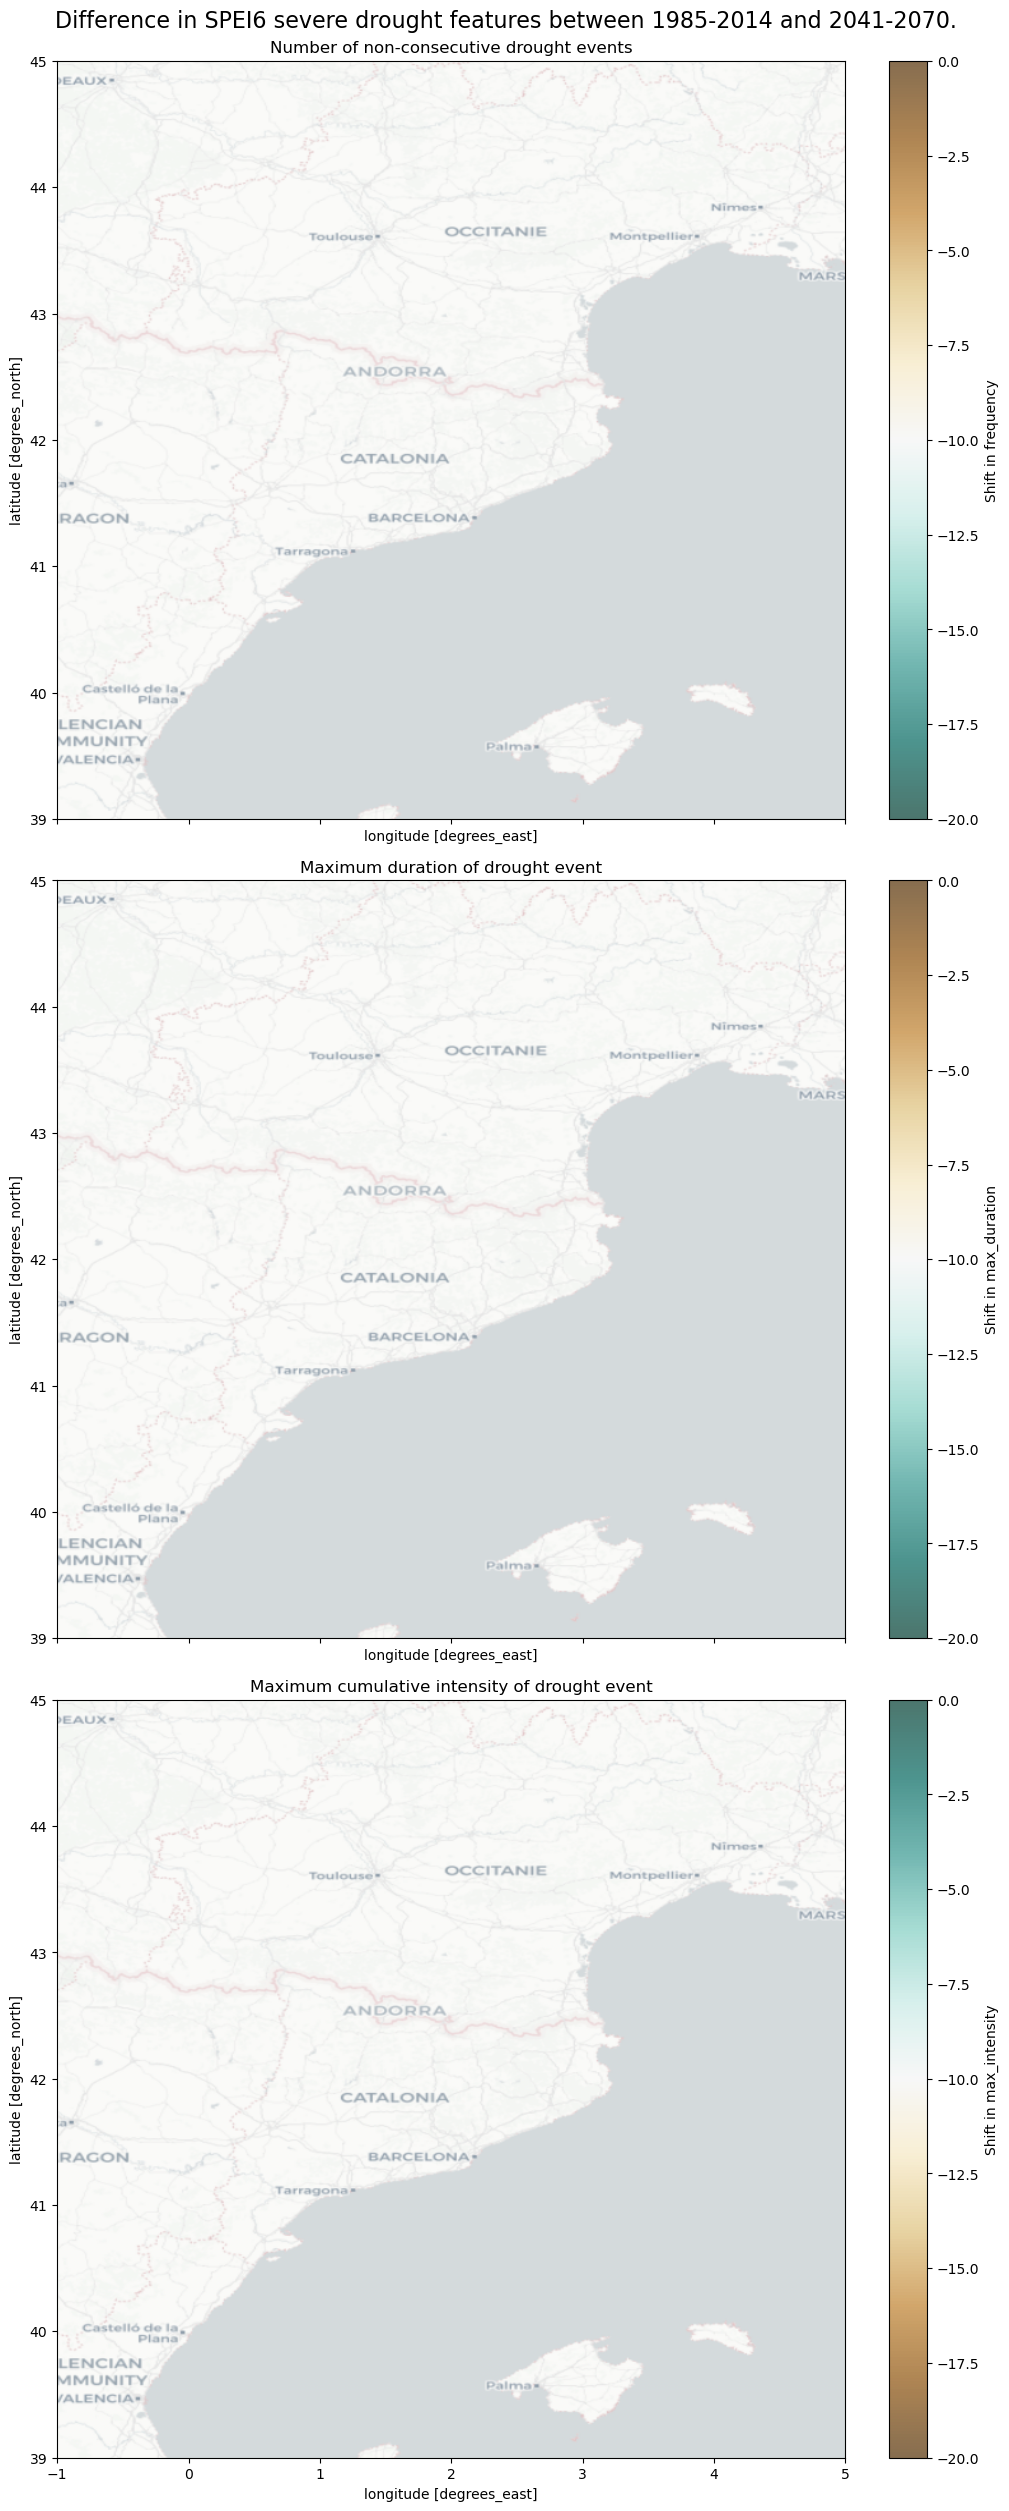

In [41]:
fig, axes = plt.subplots(3, 1, figsize = (10,25), layout = 'constrained', sharey = True, sharex=True)

# Select drought threshold
thr_class = 'severe'

paths = [glob.glob(os.path.join(results_dir,f'{thr_class}_drought_{GCM}_{run}_*_{areaname}.nc'))[0] for run in YEAR_WINDOWS.keys()]
ds = [xr.open_dataset(path_i, decode_coords = 'all') for path_i in paths]
ds_change = ds[1] - ds[0]
for j, stat in enumerate(ds[0].data_vars.variables):
    
    im = ds_change[stat].plot(ax = axes[j],
                                       cmap = 'BrBG_r' if stat != 'max_intensity' else 'BrBG',
                                       add_colorbar = False,
                                       vmin = -20,
                                       alpha = 0.7,
                                       xlim = (bbox[0]-1, bbox[2] + 1),
                                        ylim = (bbox[1]-1, bbox[3] + 1)
                                        
    )
    cbar = plt.colorbar(im)
    cbar.set_label(f"Shift in {stat}")
    ctx.add_basemap(ax = axes[j],crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution=False)
    axes[j].set_title(f"{ds[0][stat].attrs['long_name']}")

fig.suptitle(f'Difference in SPEI{T_AGG} {thr_class} drought features between 1985-2014 and 2041-2070.', fontsize= 16);
plt.show()

## Conclusions

---
## Authors


--- 

## References

